In [50]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [51]:
# --- Topological layout (top->bottom) and drawing utilities
def topo_vertical_layout(
    G: nx.DiGraph,
    layer_gap: float = 1.0,
    node_gap: float = 1.6,
    bottom_to_top: bool = False,          # ← ahora por defecto top->bottom
    stagger_singletons: bool = True,      # ← opcional: desplazar capas de 1 nodo
    singleton_dx: float = 0.8,            # ← cuánto desplazar en X
):
    """
    Positions nodes by topological generations. Sources first (top), sinks last (bottom).
    If a layer has a single node, optionally shift it horizontally so edges don't perfectly overlap.
    """
    if not nx.is_directed_acyclic_graph(G):
        return nx.spring_layout(G, seed=42)

    layers = list(nx.topological_generations(G))  # sources first, sinks last
    pos: Dict[Any, Tuple[float, float]] = {}
    L = len(layers)

    for li, layer in enumerate(layers):
        # top->bottom when bottom_to_top=False
        y = -li * layer_gap if bottom_to_top else li * layer_gap
        n = max(1, len(layer))

        if n == 1 and stagger_singletons:
            # shift singletons left/right progressively to avoid perfect vertical alignment
            x = (li - (L - 1) / 2.0) * singleton_dx
            pos[layer[0]] = (x, y)
        else:
            width = (n - 1) * node_gap
            x0 = -width / 2.0
            for j, node in enumerate(layer):
                pos[node] = (x0 + j * node_gap, y)
    return pos


def draw_dag_topo(G: nx.DiGraph, ax=None, title: Optional[str] = None):
    """
    Draw DAG with top->bottom orientation and curved edges to avoid overlap
    when multiple edges share the same vertical direction.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # top->bottom; also stagger singletons to reduce straight overlap
    pos = topo_vertical_layout(
        G, layer_gap=1.0, node_gap=1.6, bottom_to_top=False,
        stagger_singletons=True, singleton_dx=0.8
    )

    # --- Curved edges (fan-out by source) to prevent perfect overlap
    edge_color = '#555555'
    width = 1.4
    rad_step = 0.25  # curvature increment between sibling edges

    for u in G.nodes():
        targets = list(G.successors(u))
        k = len(targets)
        for idx, v in enumerate(targets):
            # center around 0, spread left/right: ..., -rad_step, 0, +rad_step, ...
            rad = (idx - (k - 1) / 2.0) * rad_step
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)], ax=ax,
                arrows=True, arrowstyle='-|>',
                width=width, edge_color=edge_color,
                connectionstyle=f'arc3,rad={rad}'
            )

    # Nodes & labels
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=600,
        node_color='#cfe8ff', edgecolors='#7aa7d7', linewidths=2.0
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight='bold')

    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return ax


# Case 1.

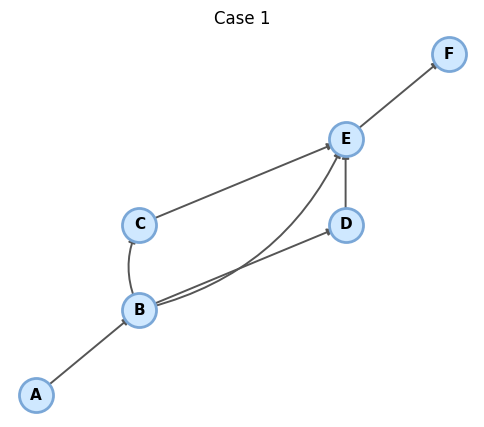

In [52]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("B", "C"),
  ("B", "D"),
  ("B", "E"),
  ("C", "E"),
  ("D", "E"),
  ("E", "F"),
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 1")
plt.show()

# Case 2.

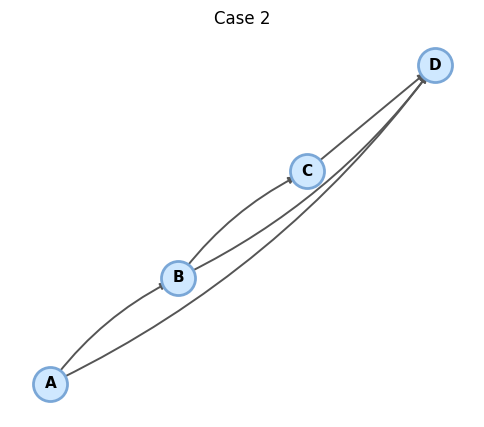

In [53]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "D"),
  ("B", "C"),
  ("B", "D"),
  ("C", "D")
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 2")
plt.show()

# Case 3.

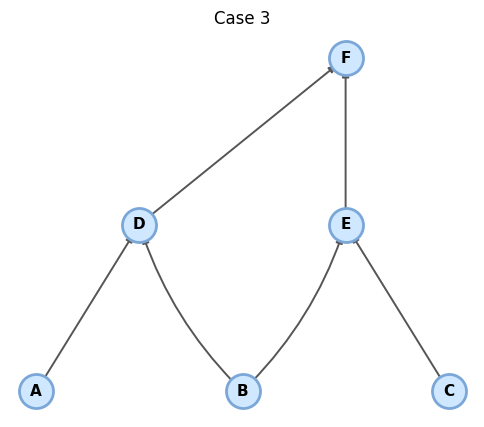

In [54]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "D"),
  ("B", "D"),
  ("B", "E"),
  ("C", "E"),
  ("D", "F"),
  ("E", "F")
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 3")
plt.show()

# Case 4

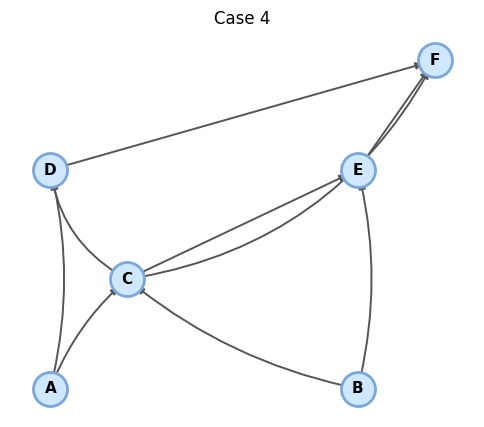

In [55]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "C"),
  ("A", "D"),
  ("B", "C"),
  ("B", "E"),
  ("C", "D"),
  ("C", "E"),
  ("C", "F"),
  ("D", "F"),
  ("E", "F")
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 4")
plt.show()

# Case 5

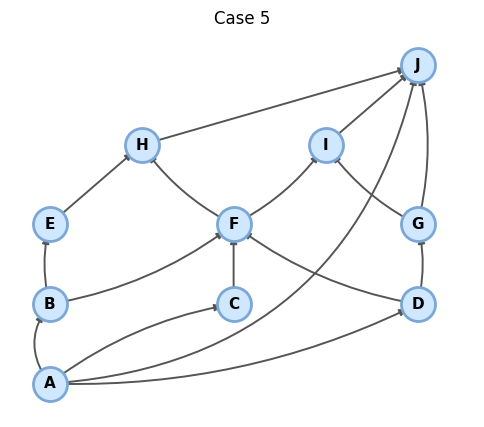

In [56]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("A", "D"),
  ("A", "J"),
  ("B", "E"),
  ("B", "F"),
  ("C", "F"),
  ("D", "F"),
  ("D", "G"),
  ("E", "H"),
  ("F", "H"),
  ("F", "I"),
  ("G", "I"),
  ("G", "J"),
  ("I", "J"),
  ("H", "J"),
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 5")
plt.show()

# Case 6

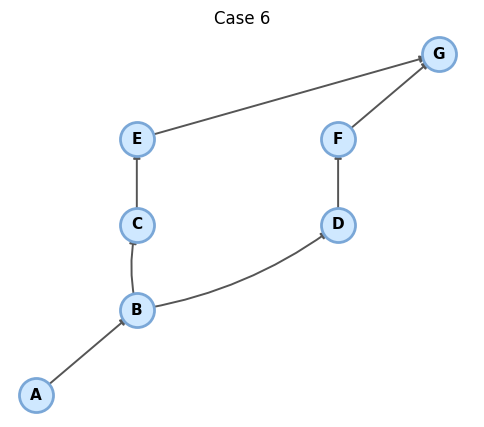

In [57]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("B", "C"),
  ("B", "D"),
  ("C", "E"),
  ("D", "F"),
  ("E", "G"),
  ("F", "G")
]


G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 6")
plt.show()

# Case 7.

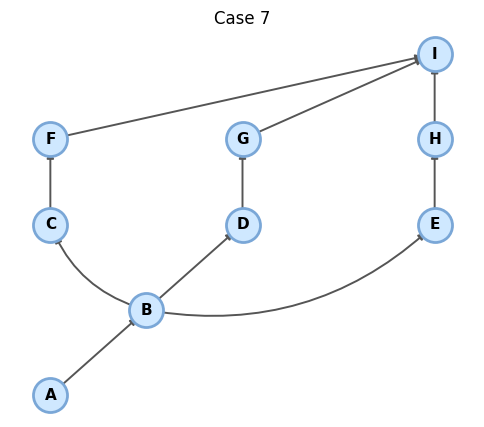

In [58]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("B", "C"),
  ("B", "D"),
  ("B", "E"),
  ("D", "G"),
  ("E", "H"),
  ("C", "F"),
  ("F", "I"),
  ("G", "I"),
  ("H", "I")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 7")
plt.show()

# Case 8.

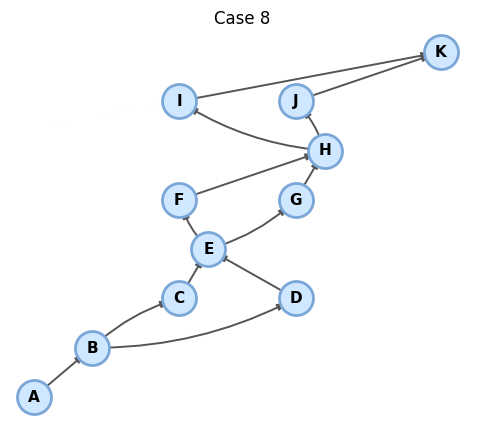

In [59]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("B", "C"),
  ("B", "D"),
  ("C", "E"),
  ("D", "E"),
  ("E", "F"),
  ("E", "G"),
  ("F", "H"),
  ("G", "H"),
  ("H", "I"),
  ("H", "J"),
  ("I", "K"),
  ("J", "K"),  
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 8")
plt.show()

# Case 9

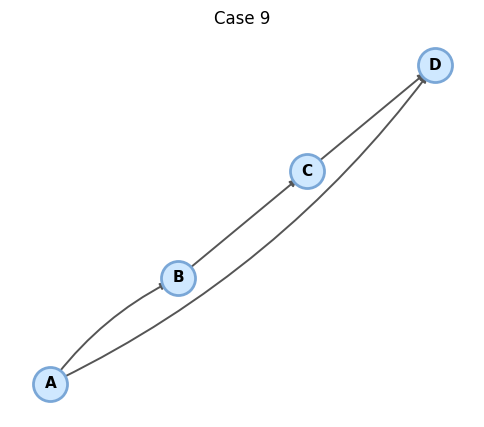

In [60]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "D"),
  ("B", "C"),
  ("C", "D")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 9")
plt.show()


# Case 10.

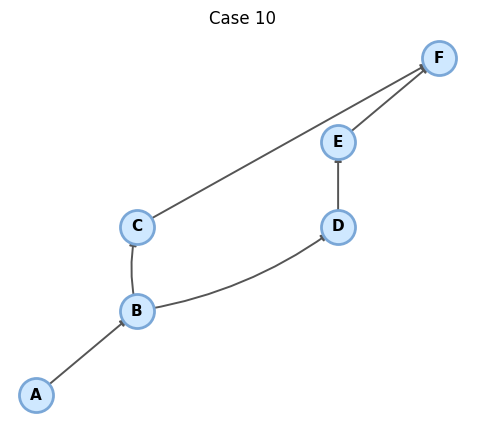

In [61]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("B", "C"),
  ("C", "F"),
  ("B", "D"),
  ("D", "E"),
  ("E", "F"),
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 10")
plt.show()


# Case 11.

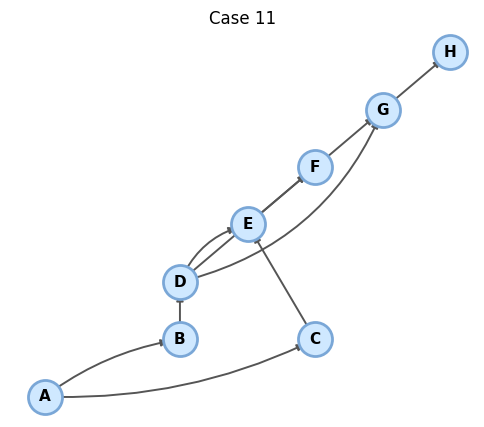

In [62]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("C", "E"),
  ("B", "D"),
  ("D", "E"),
  ("D", "F"),
  ("D", "G"),
  ("E", "F"),
  ("F", "G"),
  ("G", "H"),
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 11")
plt.show()

# Case 12.

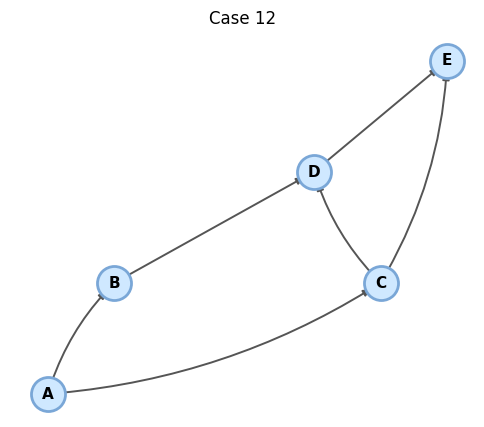

In [63]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("B", "D"),
  ("C", "D"),
  ("C", "E"),
  ("D", "E"),
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 12")
plt.show()

# Case 13.

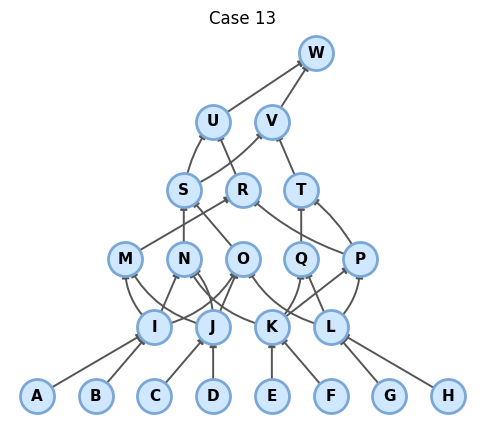

In [64]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
    ("A", "I"), ("B", "I"),
    ("C", "J"), ("D", "J"),
    ("E", "K"), ("F", "K"),
    ("G", "L"), ("H", "L"),

    ("I", "M"), ("I", "N"), ("I", "O"),
    ("J", "M"), ("J", "O"), ("J", "N"),
    ("K", "N"), ("K", "P"), ("K", "Q"),
    ("L", "O"), ("L", "Q"), ("L", "P"),

    ("M", "R"), 
    ("N", "S"),
    ("O", "S"),
    ("P", "R"), ("P", "T"),
    ("Q", "T"),


    ("R", "U"), 
    ("S", "U"), ("S", "V"),
    ("T", "V"),

    ("U", "W"), 
    ("V", "W")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 13")
plt.show()

# Case 14.

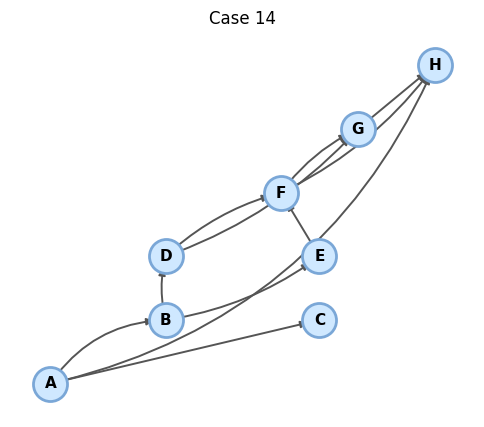

In [65]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("B", "D"),
  ("B", "E"),
  ("D", "F"),
  ("D", "G"),
  ("E", "F"),
  ("F", "G"),
  ("F", "H"),
  ("G", "H"),
  ("A", "H"),
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 14")
plt.show()

# Case 15.

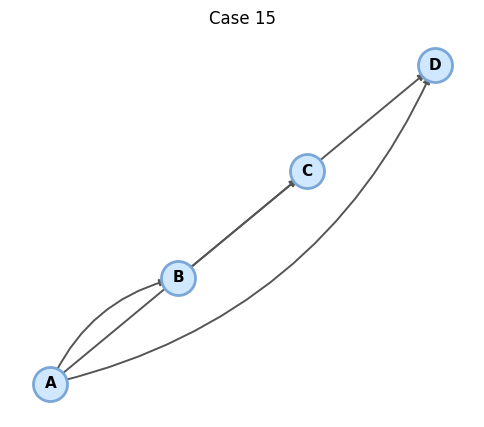

In [66]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("A", "D"),
  ("B", "C"),
  ("C", "D")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 15")
plt.show()

# Case 16

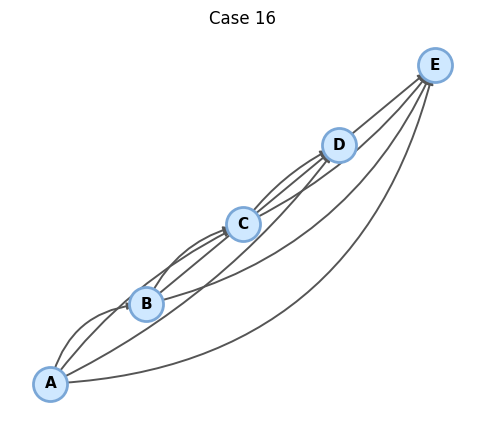

In [67]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("A", "D"),
  ("A", "E"),
  ("B", "C"),
  ("B", "D"),
  ("B", "E"),
  ("C", "D"),
  ("C", "E"),
  ("D", "E")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 16")
plt.show()

# Case 17.

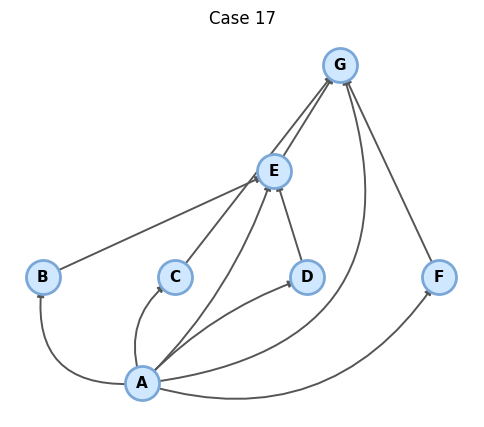

In [68]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "B"),
  ("A", "C"),
  ("A", "D"),
  ("A", "E"),
  ("A", "F"),
  ("A", "G"),
  ("B", "E"),
  ("C", "G"),
  ("D", "E"),
  ("E", "G"),
  ("F", "G"),
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 17")
plt.show()

# Case 18.

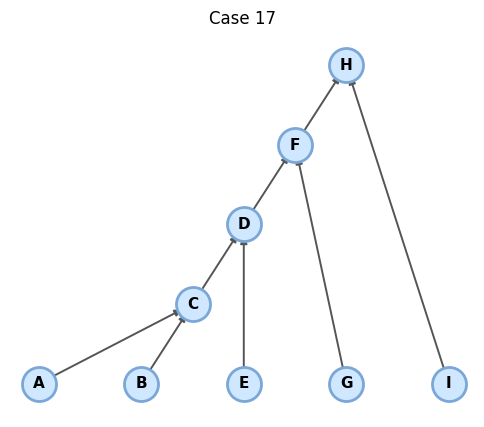

In [69]:
# Graph rendering (topological, bottom->top)
G_links: List[Tuple[str, str]] = [
  ("A", "C"),
  ("B", "C"),
  ("C", "D"),
  ("E", "D"),
  ("D", "F"),
  ("G", "F"),
  ("F", "H"),
  ("I", "H")
]



G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"Case 17")
plt.show()